In [25]:
from skimage import io, color, morphology
from skimage.util import img_as_float, img_as_ubyte
import matplotlib.pyplot as plt
import numpy as np
import math
from skimage.filters import threshold_otsu
from skimage import segmentation
from skimage import measure
from skimage.color import label2rgb
from skimage.color import rgb2gray
from skimage.morphology import erosion, dilation, opening, closing
from skimage.morphology import disk, rectangle

In [3]:
def show_comparison(original, modified, modified_name):
    fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(8, 4), sharex=True,
                                   sharey=True)
    ax1.imshow(original)
    ax1.set_title('Original')
    ax1.axis('off')
    ax2.imshow(modified)
    ax2.set_title(modified_name)
    ax2.axis('off')
    io.show()

In [ ]:
data_path = "/home/kkristjansson/DTU/spring2026/02515_Image_Analysis/imageAnalysisGithub/exercises/ex5-BLOBAnalysis/data/"

/tmp/ipykernel_228927/578429982.py:10: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


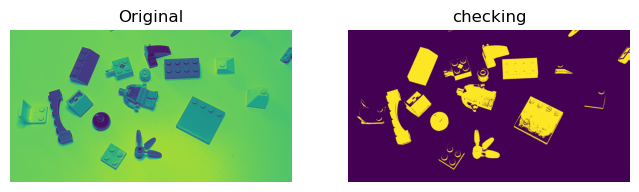

In [ ]:
# Exercise 1: Binary image from original image

img_name = "lego_4_small.png"
img = io.imread(data_path+img_name)

img_gray = color.rgb2gray(img)
img_rgb = color.rgb
threshold = threshold_otsu(img_gray)

bin_img = threshold > img_gray

show_comparison(img,bin_img,"checking")






/tmp/ipykernel_228927/578429982.py:10: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


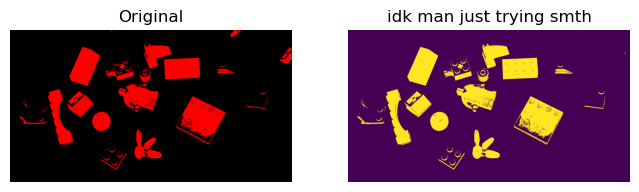

In [24]:
# Exercise 2: Remove border BLOBs

labels = label2rgb(bin_img)

cleared =  segmentation.clear_border(bin_img)

show_comparison(labels,cleared,"idk man just trying smth")



/tmp/ipykernel_228927/578429982.py:10: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


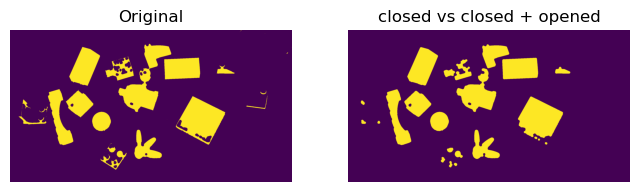

In [30]:
# Exercise 3: Cleaning using morphological operations
structure = disk(8)

img_closed = closing(cleared,structure)
img_opened = opening(img_closed,structure)

show_comparison(img_closed,img_opened,"closed vs closed + opened")

In [32]:
# Exercise 4: Find labels
label_img = measure.label(img_opened)
n_labels = label_img.max()
print(f"Number of labels: {n_labels}")



Number of labels: 23


/tmp/ipykernel_228927/578429982.py:10: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


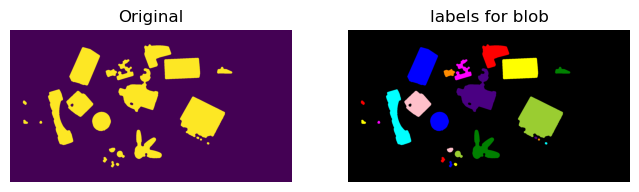

In [34]:
# Exercise 5: Visualize found labels

im_blob = label2rgb(label_img)

show_comparison(img_opened,im_blob,"labels for blob")

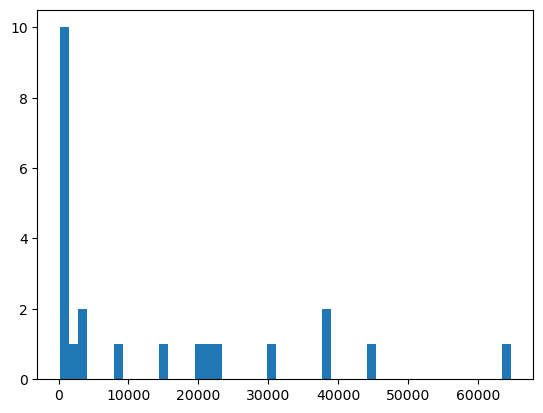

In [35]:
# Exercise 6: Compute BLOB features

region_props = measure.regionprops(label_img)
areas = np.array([prop.area for prop in region_props])
plt.hist(areas, bins=50)
plt.show()


/tmp/ipykernel_228927/697077806.py:7: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.imshow(img_gray, vmin=0, vmax=150)
/tmp/ipykernel_228927/697077806.py:9: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


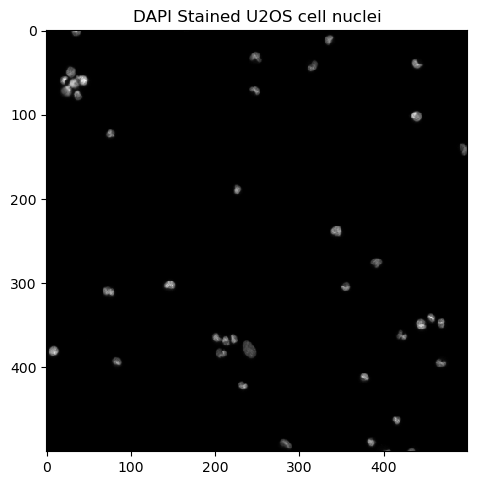

In [37]:
# Exercise cell counting:
in_dir = "data/"
img_org = io.imread(data_path + 'Sample E2 - U2OS DAPI channel.tiff')
# slice to extract smaller image
img_small = img_org[700:1200, 900:1400]
img_gray = img_as_ubyte(img_small) 
io.imshow(img_gray, vmin=0, vmax=150)
plt.title('DAPI Stained U2OS cell nuclei')
io.show()


/tmp/ipykernel_228927/158489352.py:3: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


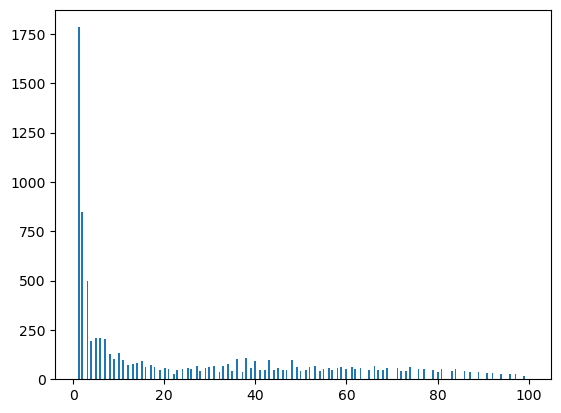

In [38]:
# avoid bin with value 0 due to the very large number of background pixels
plt.hist(img_gray.ravel(), bins=256, range=(1, 100))
io.show()

/tmp/ipykernel_228927/578429982.py:10: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


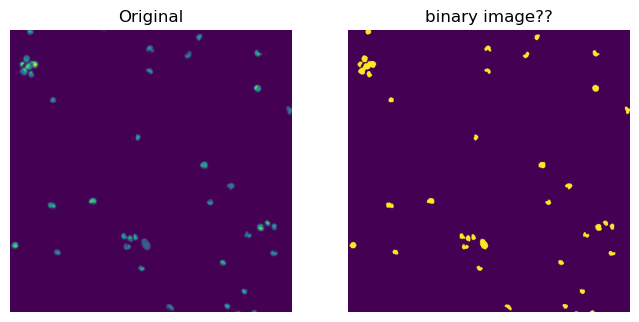

In [42]:
# Exercise 8: threshold selection


threshold = threshold_otsu(img_gray)

bin_img = img_gray > threshold

show_comparison(img_gray,bin_img,"binary image??")

/tmp/ipykernel_228927/578429982.py:10: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


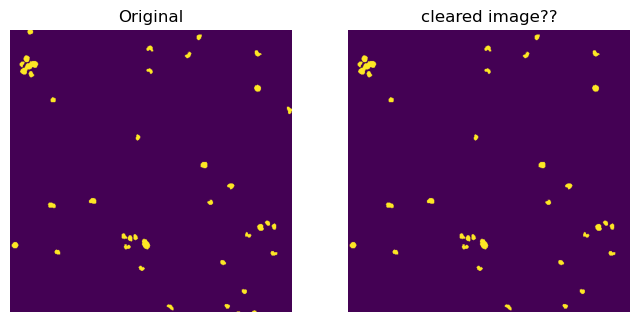

/tmp/ipykernel_228927/578429982.py:10: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


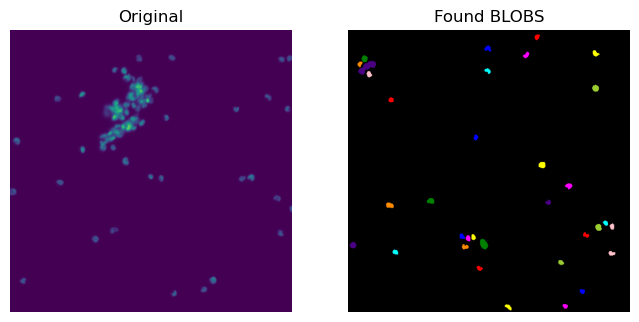

In [44]:
# Exercise 9: Removing border BLOBS

cleared = segmentation.clear_border(bin_img)
show_comparison(bin_img,cleared,"cleared image??")

label_img = measure.label(cleared)
image_label_overlay = label2rgb(label_img)
show_comparison(img_org, image_label_overlay, 'Found BLOBS')


/tmp/ipykernel_228927/1054741969.py:8: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


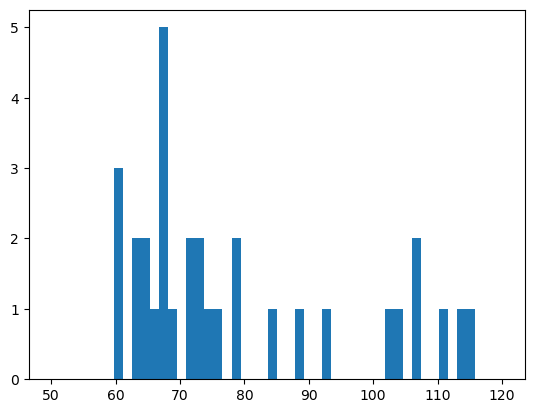

In [53]:
# Exercise 10: BLOB features

region_props = measure.regionprops(label_img)

areas = np.array([prop.area for prop in region_props])

plt.hist(areas, bins=50, range=(50, 120))
io.show()


/tmp/ipykernel_228927/578429982.py:10: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


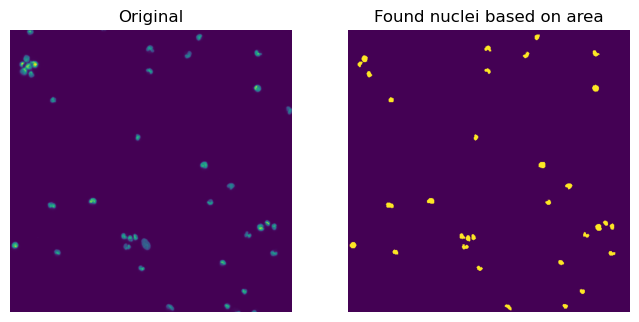

In [ ]:
# Exercise 11: BLOB classification by area



min_area = 60
max_area = 150

# Create a copy of the label_img
label_img_filter = label_img
for region in region_props:
    # Find the areas that do not fit our criteria
    if region.area > max_area or region.area < min_area:
        # set the pixels in the invalid areas to background
        for cords in region.coords:
            label_img_filter[cords[0], cords[1]] = 0
# Create binary image from the filtered label image
i_area = label_img_filter > 0
show_comparison(img_small, i_area, 'Found nuclei based on area')

<function matplotlib.pyplot.show(close=None, block=None)>

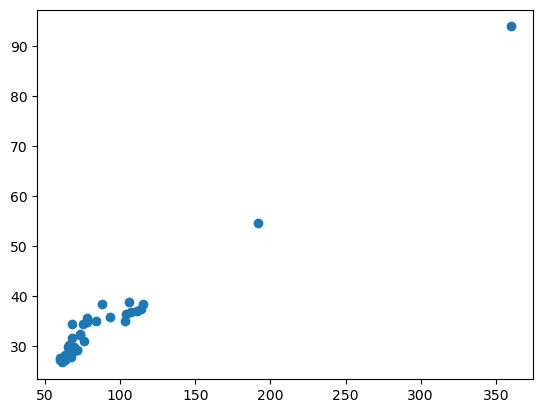

In [58]:
# Exercise 12: Feature space
perimeters = np.array([prop.perimeter for prop in region_props])


plt.scatter(areas,perimeters)
plt.show

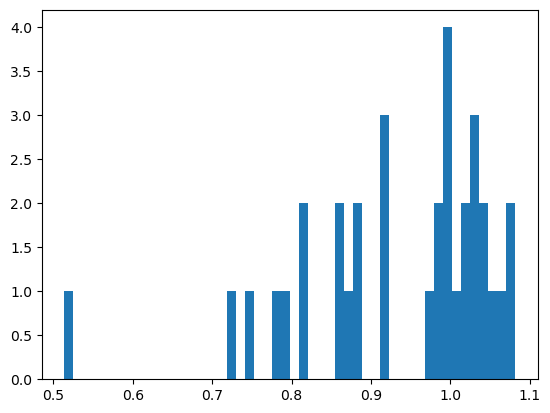

/tmp/ipykernel_228927/578429982.py:10: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


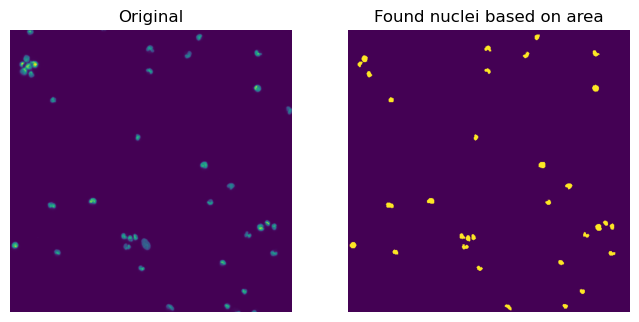

In [ ]:
# Exercise 13: BLOB Circularity
f_circ = []
for area in range(len(areas)):
    f_c = 4*math.pi*areas[area]/perimeters[area]**2
    f_circ.append(f_c)
plt.hist(f_circ, bins=50)
plt.show()




min_area = 60
max_area = 150
min_circ = 0.7


# Create a copy of the label_img
label_img_filter = label_img
for region in region_props:
    
circ = circularity(region.area, region.perimeter)
    
# Find the areas that do not fit our criteria
    
if region.area > max_area or region.area < min_area or circ < min_circ:
        
# set the pixels in the invalid areas to background
        
for cords in region.coords:
            
label_img_filter[cords[0], cords[1]] = 0

# Create binary image from the filtered label image
i_area = label_img_filter > 0
show_comparison(img_small, i_area, 'Found nuclei based on area and circularity')
